In [2]:
# import packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
#pip install intake-esgf

In [4]:
# import ESGF catalogue & download daily data for tasmax from the CanESM5 model
#from intake_esgf import ESGFCatalog

#cat = (
   # ESGFCatalog()
    #.search(
        #experiment_id="historical",
       # source_id="CanESM5",
       # variable_id="tasmax",
       # frequency="day",
       # file_start="1900-01",
       # file_end="2020-01",
   # )
    #.remove_ensembles()
#)
#dpd = cat.to_path_dict(minimal_keys=False)


In [5]:
# download the collected data into an xarray
#dsd = cat.to_dataset_dict()

In [6]:
# plots not working...
#fig, axs = plt.subplots(figsize=(6, 12), nrows=3)

# temperature
#ds = dsd["tasmax"]["tasmax"].mean(dim="time") - 273.15  # to [C]
#ds.plot(ax=axs[0], cmap="bwr", vmin=-40, vmax=40, cbar_kwargs={"label": "tas [C]"})

# precipitation
#ds = dsd["pr"]["pr"].mean(dim="time") * 86400 / 999.8 * 1000  # to [mm d-1]
#ds.plot(ax=axs[1], cmap="Blues", vmax=10, cbar_kwargs={"label": "pr [mm d-1]"})

# gross primary productivty
#ds = dsd["gpp"]["gpp"].mean(dim="time") * 86400 * 1000  # to [g m-2 d-1]
#ds.plot(ax=axs[2], cmap="Greens", cbar_kwargs={"label": "gpp [g m-2 d-1]"})
#plt.tight_layout()

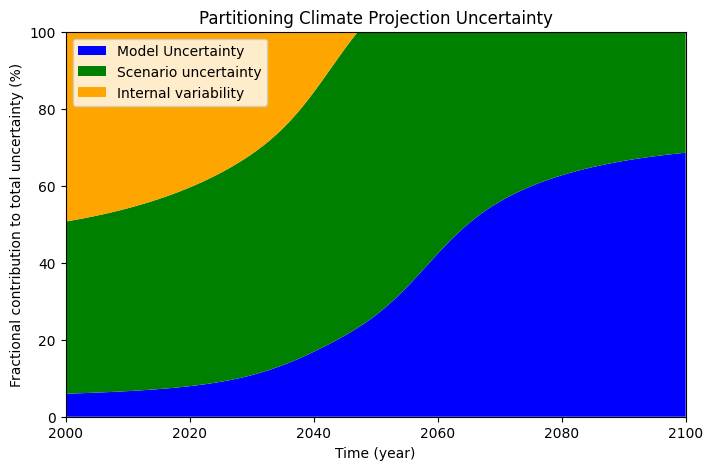

In [36]:
years = np.arange(2000, 2101)

# internal variability
internal_variability = (5 * np.exp(-(years-2000)/20))


# model uncertainty
model_uncertainty = (0.25 + 0.15 * np.exp(-((years-2050)**2)/(100)))

# scenario uncertainty
scenario_uncertainty = (0.05 + 0.45 * (1 / (1 + np.exp(-(years-2055)/10)))) 

# normalize
total = internal_variability + scenario_uncertainty + model_uncertainty
internal_variability /= total
scenario_uncertainty /= total
model_uncertainty /= total

# convert to percentages
internal_variability *= 100
model_uncertainty *= 100
scenario_uncertainty *= 100

internal_variability = internal_variability + 40
model_uncertainty = model_uncertainty + 40
scenario_uncertainty = scenario_uncertainty + 5

# creating plots
plt.figure(figsize=(8,5))

plt.stackplot(
    years,
    scenario_uncertainty,
    model_uncertainty,
    internal_variability,
    colors=['blue', 'green', 'orange'], 
    labels=["Model Uncertainty", "Scenario uncertainty", "Internal variability"]
)

plt.xlabel("Time (year)")
plt.ylabel("Fractional contribution to total uncertainty (%)")
plt.title("Partitioning Climate Projection Uncertainty")
plt.legend(loc="upper left")

plt.xlim(2000,2100)
plt.ylim(0,100)

plt.show()

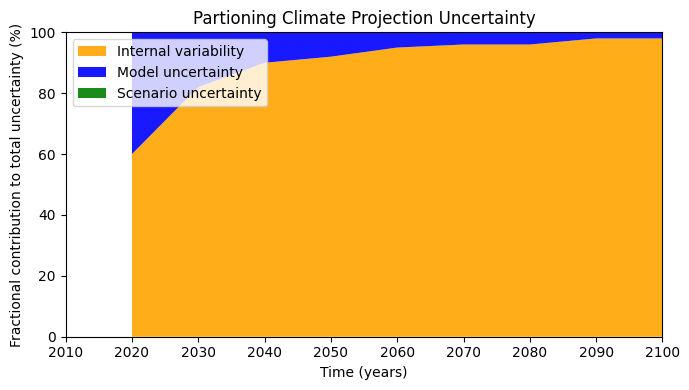

In [42]:
years = [2020,2030,2040,2050,2060,2070,2080,2090,2100]

internal = [60,82,90,92,95,96,96,98,98]
model    = [60,77,75,70,65,63,58,52,45]
scenario = [60,77,83,90,92,94,94,96,96]

plt.figure(figsize=(7,4))

plt.stackplot(
    years,
    internal,
    model,
    scenario,
    colors=["orange","blue","green"],
    labels=["Internal variability","Model uncertainty","Scenario uncertainty"],
    alpha=0.9
)

plt.xlabel("Time (years)")
plt.ylabel("Fractional contribution to total uncertainty (%)")
plt.title('Partioning Climate Projection Uncertainty')

plt.ylim(0,100)
plt.xlim(2010,2100)

plt.legend(loc="upper left")

plt.tight_layout()
plt.show()